In [2]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *

# S1

100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


estimated p ≈ 0.9899, C ≈ 5.1026e-04, using 23 points


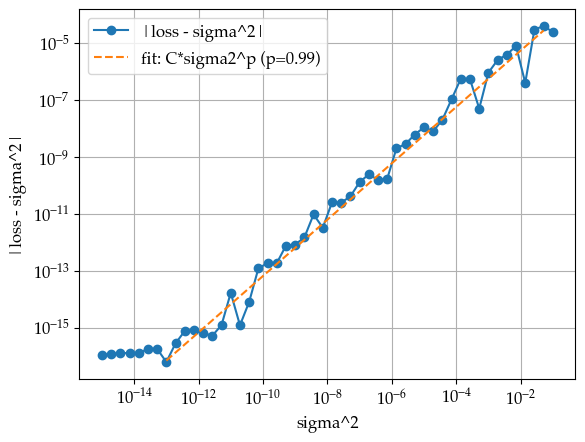

In [3]:
manifold_type = 'S1'
manifold  = get_manifold(manifold_type)

n_samples = 1000000
G =lambda n: uniform_sampler(manifold_type, n ) 
# =======


Theta = G(n_samples)
sigma2s = np.logspace(-15,-1)
losses = np.zeros_like(sigma2s)
for ix, sigma2 in tqdm(enumerate(sigma2s), total=len(sigma2s)):
    X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
    losses[ix] =  sq_loss(manifold, X, Theta)
plt.show()
resid = losses - (1)*sigma2s
mask = resid > 0  # needed for log
sigma2_max = 1
mask = (sigma2s <= sigma2_max) & (resid > 0)

xs = np.log(sigma2s[mask])
ys = np.log(resid[mask])

p, a = np.polyfit(xs, ys, 1)  # slope=p, intercept=a
C = np.exp(a)
# p = np.dot(xs, ys) / np.dot(xs, xs)
# a = 0.0
# C = 1.0

print(f"estimated p ≈ {p:.4f}, C ≈ {C:.4e}, using {mask.sum()} points")
# plot
plt.figure()
plt.loglog(sigma2s, np.abs(resid), "o-", label="|loss - sigma^2|")
plt.loglog(
    sigma2s[mask],
    C * (sigma2s[mask] ** p),
    "--",
    label=f"fit: C*sigma2^p (p={p:.2f})",
)
plt.xlabel("sigma^2")
plt.ylabel("|loss - sigma^2|")
plt.legend()
plt.grid(True, which="both")
plt.show()

# S2

100%|██████████| 50/50 [00:52<00:00,  1.05s/it]


estimated p ≈ 1.0005, C ≈ 1.0007e+00, using 50 points


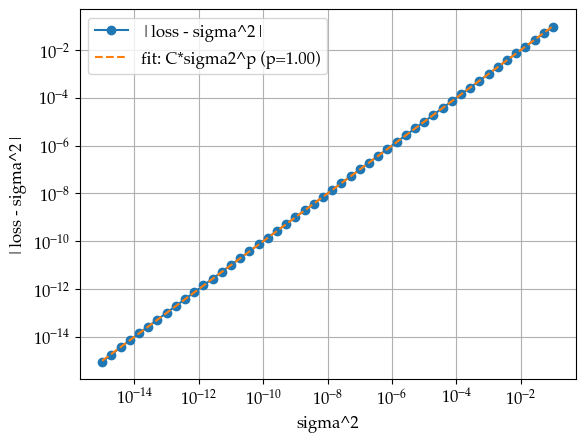

In [4]:
manifold_type = 'S2'
manifold  = get_manifold(manifold_type)

n_samples = 1000000
G =lambda n: uniform_sampler(manifold_type, n ) 
# =======


Theta = G(n_samples)
sigma2s = np.logspace(-15,-1)
losses = np.zeros_like(sigma2s)
for ix, sigma2 in tqdm(enumerate(sigma2s), total=len(sigma2s)):
    X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
    losses[ix] =  sq_loss(manifold, X, Theta)
plt.show()
resid = losses - (1)*sigma2s
mask = resid > 0  # needed for log
sigma2_max = 1
mask = (sigma2s <= sigma2_max) & (resid > 0)

xs = np.log(sigma2s[mask])
ys = np.log(resid[mask])

p, a = np.polyfit(xs, ys, 1)  # slope=p, intercept=a
C = np.exp(a)
# p = np.dot(xs, ys) / np.dot(xs, xs)
# a = 0.0
# C = 1.0

print(f"estimated p ≈ {p:.4f}, C ≈ {C:.4e}, using {mask.sum()} points")
# plot
plt.figure()
plt.loglog(sigma2s, np.abs(resid), "o-", label="|loss - sigma^2|")
plt.loglog(
    sigma2s[mask],
    C * (sigma2s[mask] ** p),
    "--",
    label=f"fit: C*sigma2^p (p={p:.2f})",
)
plt.xlabel("sigma^2")
plt.ylabel("|loss - sigma^2|")
plt.legend()
plt.grid(True, which="both")
plt.show()